<a href="https://colab.research.google.com/github/2405018timo/ML_PROJECTS-BY-TIMOTHY-MUGO/blob/main/KNN_Heart_Failure_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

#importing data handling,visualiztion and essential ML and KNN libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
#Loading the Excel dataset into a DataFrame
df= pd.read_csv('heart_failure_clinical_records_dataset.csv')

In [ ]:
# # Display column names, data types, and missing values
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [ ]:
#counting how many patients survived vs died
df['DEATH_EVENT'].value_counts()

,count
DEATH_EVENT,
0,203
1,96


In [ ]:
#Separate Features and Target
# X contains all input features
# y contains the target variable
X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

In [ ]:
#Train–Test Split
# Split data: 80% training, 20% testing
#prevents oerfitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Feature Scaling since its distance based
# Create a scaler object
scaler = StandardScaler()
# Fit scaler on training data and transform
X_train = scaler.fit_transform(X_train)
# Transform test data using same scale
X_test = scaler.transform(X_test)

In [ ]:
#Train the KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
#Model will look at 5 closest patients to decide outcome
#training model
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
#Make Predictions
y_pred = knn.predict(X_test)

In [ ]:
#Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6833333333333333


In [ ]:
#confusion matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[34  1]
 [18  7]]


In [ ]:
#key performance metrics
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.97      0.78        35
           1       0.88      0.28      0.42        25

    accuracy                           0.68        60
   macro avg       0.76      0.63      0.60        60
weighted avg       0.75      0.68      0.63        60



In [ ]:
#Improving model by choosing Best K
error_rates = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    error_rates.append(np.mean(pred != y_test))

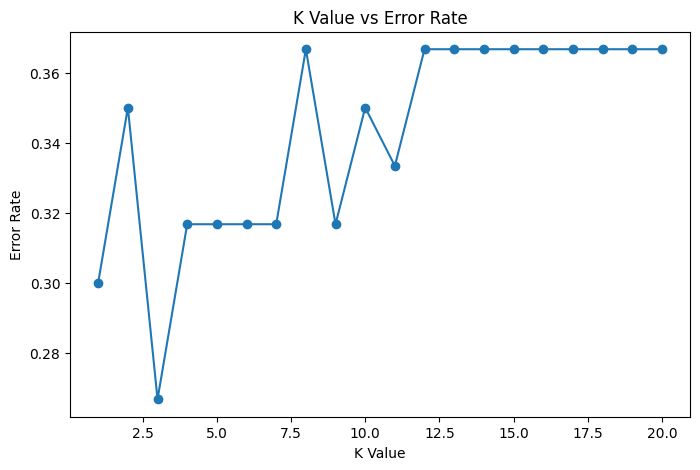

In [ ]:
#Plot Error vs K
#Lowest point = best performance
plt.figure(figsize=(8,5))
plt.plot(range(1,21), error_rates, marker='o')
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.title("K Value vs Error Rate")
plt.show()

In [ ]:
#Retrain with Best K
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

final_pred = knn.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, final_pred))

Final Accuracy: 0.7333333333333333
